# ![Machine Learning Lab](banner.jpg)

# Laboratorio 7 - Actividad

## Instrucciones generales

1. Esta actividad es de carácter individual. No se permite entregar la actividad después de la fecha establecida.
2. Al responder las preguntas de las actividades, por favor marquen las respuestas con la sección a la que corresponden, por ejemplo: `## 1.1 Carga de datos`. Es preferible que esto lo hagan con secciones de MarkDown.
3. Por favor asegurarse de que el notebook entregado tenga todas las celdas ejecutadas correctamente.
4. Por favor, nombren el archivo de acuerdo con el siguiente formato `{email}_lab7.ipynb`.
5. Si tienen alguna duda, pueden escribirme a mi correo `j.rayom@uniandes.edu.co` o contactarme directamente por Teams.

---

## Objetivos

1. Construir y entrenar un Perceptrón Multicapa (MLP) para clasificación multiclase.
2. Implementar el mismo modelo en dos frameworks: **PyTorch** y **TensorFlow/Keras**.
3. Evaluar y comparar el desempeño de ambos modelos.

---

En esta ocasión trabajaremos con el dataset **Blood Cell Anomaly Detection 2025**, que contiene 5,880 registros de células sanguíneas con 36 características morfológicas, clínicas y de adquisición. El objetivo es clasificar cada registro en uno de los **19 tipos de célula** disponibles.

Dataset: [Blood Cell Anomaly Detection 2025](https://www.kaggle.com/datasets/alitaqishah/blood-cell-anomaly-detection-2025)

---

## Instrucciones

### 1. Carga y exploración de datos (10%)

1. Descarga el archivo `blood_cell_anomaly_detection.csv` desde Kaggle.
2. Carga el CSV en un DataFrame y muestra las primeras filas.
3. Identifica la columna objetivo (`cell_type`) y muestra la distribución de las 19 clases.
4. ¿Cuántas características numéricas y categóricas tiene el dataset? ¿Hay valores faltantes?

---

### 2. Preprocesamiento de datos (20%)

Las siguientes columnas **no deben usarse** como features: `anomaly_label`, `disease_category`, `cytodiffusion_anomaly_score`, `cytodiffusion_classification_confidence`, `labeller_confidence_score`.

1. Elimina las columnas mencionadas y el identificador (`cell_id`).
2. Normaliza las features numéricas (escalar al rango [0,1] o estandarizar).
3. Aplica **one-hot encoding** a las features categóricas y combínalas con las numéricas.
4. Codifica la columna objetivo (`cell_type`) como valores numéricos.
5. Divide los datos en conjunto de entrenamiento (80%) y prueba (20%). Utiliza `random_state = 42`

---

### 3. MLP con PyTorch (30%)

1. Convierte los datos de entrenamiento y prueba a tensores de PyTorch y crea DataLoaders.
2. Construye un MLP usando `nn.Module` con al menos 2 capas ocultas y activación ReLU.
3. ¿Cuántos parámetros tiene la red? Muestra la cantidad de parametros por cada capa.
4. Entrena el modelo por al menos 20 épocas. Grafica la curva de pérdida.
5. Evalúa el modelo en el conjunto de prueba y reporta la precisión (accuracy).

---

### 4. MLP con TensorFlow/Keras (30%)

1. Construye un MLP equivalente al anterior usando la API Sequential de Keras.
2. Compila el modelo con el optimizador y función de pérdida adecuados.
3. Entrena el modelo por al menos 20 épocas. Grafica la curva de pérdida.
4. Evalúa el modelo en el conjunto de prueba y reporta la precisión (accuracy).

---

### 5. Comparación de resultados (10%)

1. Genera la matriz de confusión para los modelos MLP.
2. ¿Cuáles tipos de célula son más difíciles de clasificar? ¿Son los mismos en ambos modelos?
3. Compara la precisión obtenida con PyTorch vs TensorFlow.

---


# Solución

## 1. Carga y exploración de datos

### 1.1. Descarga del dataset

In [4]:
!mkdir data/
!curl -L -o data/blood-cell-anomaly-detection-2025.zip\
  https://www.kaggle.com/api/v1/datasets/download/alitaqishah/blood-cell-anomaly-detection-2025
!unzip data/blood-cell-anomaly-detection-2025.zip -d data/blood-cell-anomaly-detection-2025

mkdir: cannot create directory ‘data/’: File exists
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  379k  100  379k    0     0   256k      0  0:00:01  0:00:01 --:--:-- 1292k
Archive:  data/blood-cell-anomaly-detection-2025.zip
  inflating: data/blood-cell-anomaly-detection-2025/blood_cell_anomaly_detection.csv  
  inflating: data/blood-cell-anomaly-detection-2025/cell_type_reference.csv  
  inflating: data/blood-cell-anomaly-detection-2025/cytodiffusion_benchmark_scores.csv  


### 1.2. Carga del CSV

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/blood-cell-anomaly-detection-2025/blood_cell_anomaly_detection.csv')
df.head()

,cell_id,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,...,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
0,CELL_005371,Hypersegmented_Neutrophil,1,Infection,15.18,58.8,0.542,0.301,0.563,0.529,...,85.5,31.4,CytoData,Giemsa,Zeiss_Axio,100,224,0.7649,0.5726,0.5670
1,CELL_005300,Hypersegmented_Neutrophil,1,Infection,16.47,73.6,0.583,0.365,0.859,0.443,...,92.5,35.0,PBC_Dataset,Wright,Zeiss_Axio,100,224,0.8472,0.7150,0.7273
2,CELL_000200,Neutrophil,0,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,...,76.3,33.0,CytoData,Wright,Leica_DM2000,100,512,0.0313,0.9225,0.9623
3,CELL_003269,Normal_RBC,0,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,...,92.3,32.5,CytoData,Wright,Leica_DM2000,100,512,0.1293,0.9180,0.8652
4,CELL_003505,Normal_RBC,0,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,...,83.9,33.4,CytoData,Wright,Olympus_BX51,100,224,0.1418,0.9697,0.8898


### 1.3. Distribución de clases

Columna objetivo: cell_type
Número de clases: 19

cell_type
Neutrophil                   1100
Normal_RBC                    900
Lymphocyte                    850
Monocyte                      400
Eosinophil                    300
Platelet                      300
Blast_Cell                    280
Elliptocyte                   200
Prolymphocyte                 180
Schistocyte                   170
Hypersegmented_Neutrophil     160
Reactive_Lymphocyte           150
Basophil                      150
Spherocyte                    150
Sickle_Cell                   140
Toxic_Granulation             140
Target_Cell                   130
Smudge_Cell                   100
Artefact                       80


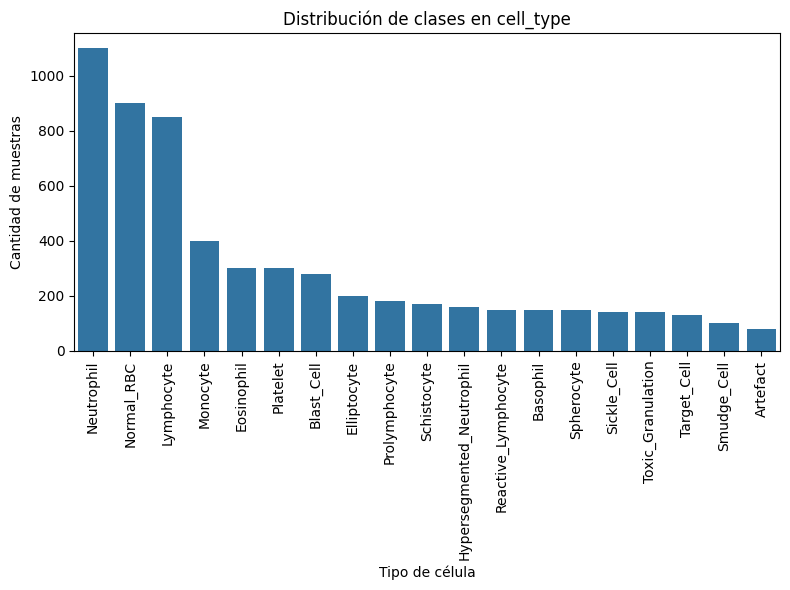

In [2]:
print(f"Columna objetivo: cell_type")
print(f"Número de clases: {df['cell_type'].nunique()}\n")
print(df['cell_type'].value_counts().to_string())

%matplotlib inline

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='cell_type', order=df['cell_type'].value_counts().index)

plt.title('Distribución de clases en cell_type')
plt.xlabel('Tipo de célula')
plt.ylabel('Cantidad de muestras')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 1.4. Características y valores faltantes

In [3]:
feature_cols = [c for c in df.columns]
numeric_features = df[feature_cols].select_dtypes(include='number').columns.tolist()
categorical_features = df[feature_cols].select_dtypes(include='object').columns.tolist()

print(f"Features numéricas ({len(numeric_features)}):\n - {"\n - ".join(numeric_features)}")
print(f"\nFeatures categóricas ({len(categorical_features)}):\n - {"\n - ".join(categorical_features)}")
missing = df.isnull().sum()
print(f"\nValores faltantes: {'Ninguno' if missing.sum() == 0 else missing[missing > 0].to_string()}")

Features numéricas (28):
 - anomaly_label
 - cell_diameter_um
 - nucleus_area_pct
 - chromatin_density
 - cytoplasm_ratio
 - circularity
 - eccentricity
 - granularity_score
 - lobularity_score
 - membrane_smoothness
 - cell_area_px
 - perimeter_px
 - mean_r
 - mean_g
 - mean_b
 - stain_intensity
 - wbc_count_per_ul
 - rbc_count_millions_per_ul
 - hemoglobin_g_dl
 - hematocrit_pct
 - platelet_count_per_ul
 - mcv_fl
 - mchc_g_dl
 - magnification_x
 - image_resolution_px
 - cytodiffusion_anomaly_score
 - cytodiffusion_classification_confidence
 - labeller_confidence_score

Features categóricas (8):
 - cell_id
 - cell_type
 - disease_category
 - patient_age_group
 - patient_sex
 - dataset_source
 - staining_protocol
 - microscope_model

Valores faltantes: Ninguno


## 2. Preprocesamiento de datos

### 2.1. Eliminar columnas

In [4]:
exclude = ['cell_id', 'anomaly_label', 'disease_category',
           'cytodiffusion_anomaly_score', 'cytodiffusion_classification_confidence',
           'labeller_confidence_score']
df_clean = df.drop(columns=exclude)
print(f"Forma: {df_clean.shape}")
df_clean.head()

Forma: (5880, 30)


,cell_type,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,granularity_score,lobularity_score,membrane_smoothness,...,hemoglobin_g_dl,hematocrit_pct,platelet_count_per_ul,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px
0,Hypersegmented_Neutrophil,15.18,58.8,0.542,0.301,0.563,0.529,4.11,6.6,0.800,...,11.7,43.4,257383,85.5,31.4,CytoData,Giemsa,Zeiss_Axio,100,224
1,Hypersegmented_Neutrophil,16.47,73.6,0.583,0.365,0.859,0.443,2.50,6.3,0.737,...,13.9,42.2,302274,92.5,35.0,PBC_Dataset,Wright,Zeiss_Axio,100,224
2,Neutrophil,13.41,55.5,0.448,0.376,0.781,0.407,3.01,3.2,0.790,...,16.1,39.2,229996,76.3,33.0,CytoData,Wright,Leica_DM2000,100,512
3,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,0.43,1.0,0.937,...,14.6,54.1,130720,92.3,32.5,CytoData,Wright,Leica_DM2000,100,512
4,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,0.51,1.0,0.925,...,14.6,36.7,228652,83.9,33.4,CytoData,Wright,Olympus_BX51,100,224


### 2.2. Normalización de features numéricas

In [5]:
from sklearn.preprocessing import MinMaxScaler

numeric_cols = df_clean.select_dtypes(include='number').columns.tolist()
scaler = MinMaxScaler()
df_clean = df_clean.copy()
df_clean[numeric_cols] = scaler.fit_transform(df_clean[numeric_cols])
df_clean[numeric_cols].describe().round(3)

,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,granularity_score,lobularity_score,membrane_smoothness,cell_area_px,...,stain_intensity,wbc_count_per_ul,rbc_count_millions_per_ul,hemoglobin_g_dl,hematocrit_pct,platelet_count_per_ul,mcv_fl,mchc_g_dl,magnification_x,image_resolution_px
count,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,...,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000
mean,0.455,0.440,0.391,0.541,0.744,0.369,0.314,0.124,0.779,0.367,...,0.446,0.381,0.548,0.558,0.522,0.439,0.482,0.550,0.600,0.390
std,0.180,0.338,0.310,0.353,0.176,0.204,0.238,0.198,0.135,0.196,...,0.158,0.157,0.165,0.139,0.138,0.152,0.165,0.148,0.417,0.389
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.329,0.000,0.000,0.238,0.679,0.217,0.112,0.000,0.696,0.201,...,0.316,0.276,0.440,0.466,0.428,0.334,0.372,0.450,0.333,0.000
50%,0.449,0.551,0.480,0.423,0.783,0.334,0.220,0.000,0.794,0.364,...,0.444,0.382,0.550,0.555,0.521,0.440,0.482,0.550,1.000,0.111
75%,0.588,0.730,0.635,1.000,0.866,0.461,0.497,0.210,0.885,0.504,...,0.567,0.487,0.661,0.651,0.617,0.543,0.595,0.650,1.000,0.472
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


### 2.3. One-hot encoding de features categóricas

In [40]:
categorical_cols = df_clean.select_dtypes(include='object').columns.difference(['cell_type']).tolist()
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols)
print(f"Forma después del encoding: {df_encoded.shape}")
df_encoded.head()

Forma después del encoding: (5880, 39)


,cell_type,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,granularity_score,lobularity_score,membrane_smoothness,...,microscope_model_Olympus_BX51,microscope_model_Zeiss_Axio,patient_age_group_Adult,patient_age_group_Elderly,patient_age_group_Pediatric,patient_sex_F,patient_sex_M,staining_protocol_Giemsa,staining_protocol_May_Grunwald_Giemsa,staining_protocol_Wright
0,Hypersegmented_Neutrophil,0.702676,0.593939,0.542,0.264211,0.514444,0.534343,0.685000,0.903226,0.718310,...,False,True,False,True,False,True,False,True,False,False
1,Hypersegmented_Neutrophil,0.766601,0.743434,0.583,0.331579,0.843333,0.447475,0.416667,0.854839,0.629577,...,False,True,False,True,False,False,True,False,False,True
2,Neutrophil,0.614965,0.560606,0.448,0.343158,0.756667,0.411111,0.501667,0.354839,0.704225,...,False,False,True,False,False,False,True,False,False,True
3,Normal_RBC,0.315164,0.000000,0.000,1.000000,0.866667,0.168687,0.071667,0.000000,0.911268,...,False,False,True,False,False,True,False,False,False,True
4,Normal_RBC,0.323588,0.000000,0.000,1.000000,1.000000,0.159596,0.085000,0.000000,0.894366,...,True,False,False,True,False,False,True,False,False,True


### 2.4. Codificación del target

In [39]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df_encoded['cell_type'])
X = df_encoded.drop(columns=['cell_type']).values.astype('float32')

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Clases ({len(le.classes_)}):\n - " + "\n - ".join(le.classes_))

X shape: (5880, 38)
y shape: (5880,)
Clases (19):
 - Artefact
 - Basophil
 - Blast_Cell
 - Elliptocyte
 - Eosinophil
 - Hypersegmented_Neutrophil
 - Lymphocyte
 - Monocyte
 - Neutrophil
 - Normal_RBC
 - Platelet
 - Prolymphocyte
 - Reactive_Lymphocyte
 - Schistocyte
 - Sickle_Cell
 - Smudge_Cell
 - Spherocyte
 - Target_Cell
 - Toxic_Granulation


## 3. MLP con PyTorch

### 3.1. Tensores y DataLoaders

### 2.5. División en conjuntos de entrenamiento y prueba

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Entrenamiento: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Prueba: X_test={X_test.shape}, y_test={y_test.shape}")

Entrenamiento: X_train=(4704, 38), y_train=(4704,)
Prueba: X_test=(1176, 38), y_test=(1176,)


In [9]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train)
X_test_t  = torch.tensor(X_test)
y_test_t  = torch.tensor(y_test)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=64)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Train batches: 74, Test batches: 19


### 3.2. Construcción del modelo MLP

In [10]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super().__init__()
        layers = []
        in_features = input_size
        for h in hidden_sizes:
            layers.extend([nn.Linear(in_features, h), nn.ReLU()])
            in_features = h
        layers.append(nn.Linear(in_features, output_size))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

model_pt = MLP(input_size=X_train.shape[1], hidden_sizes=[256, 128, 64], output_size=19)
print(model_pt)

MLP(
  (network): Sequential(
    (0): Linear(in_features=38, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=19, bias=True)
  )
)


### 3.3. Parámetros del modelo

In [11]:
total_params = 0
for name, param in model_pt.named_parameters():
    n = param.numel()
    print(f"{name}: {n:,} parámetros")
    total_params += n
print(f"\nTotal de parámetros: {total_params:,}")

network.0.weight: 9,728 parámetros
network.0.bias: 256 parámetros
network.2.weight: 32,768 parámetros
network.2.bias: 128 parámetros
network.4.weight: 8,192 parámetros
network.4.bias: 64 parámetros
network.6.weight: 1,216 parámetros
network.6.bias: 19 parámetros

Total de parámetros: 52,371


### 3.4. Entrenamiento y curva de pérdida

Época  1/20 — Pérdida: 2.3392
Época  2/20 — Pérdida: 1.3203
Época  3/20 — Pérdida: 0.7343
Época  4/20 — Pérdida: 0.4724
Época  5/20 — Pérdida: 0.3657
Época  6/20 — Pérdida: 0.3331
Época  7/20 — Pérdida: 0.2835
Época  8/20 — Pérdida: 0.2547
Época  9/20 — Pérdida: 0.2238
Época 10/20 — Pérdida: 0.2156
Época 11/20 — Pérdida: 0.2028
Época 12/20 — Pérdida: 0.1874
Época 13/20 — Pérdida: 0.1909
Época 14/20 — Pérdida: 0.1710
Época 15/20 — Pérdida: 0.1723
Época 16/20 — Pérdida: 0.1644
Época 17/20 — Pérdida: 0.1656
Época 18/20 — Pérdida: 0.1650
Época 19/20 — Pérdida: 0.1535
Época 20/20 — Pérdida: 0.1528


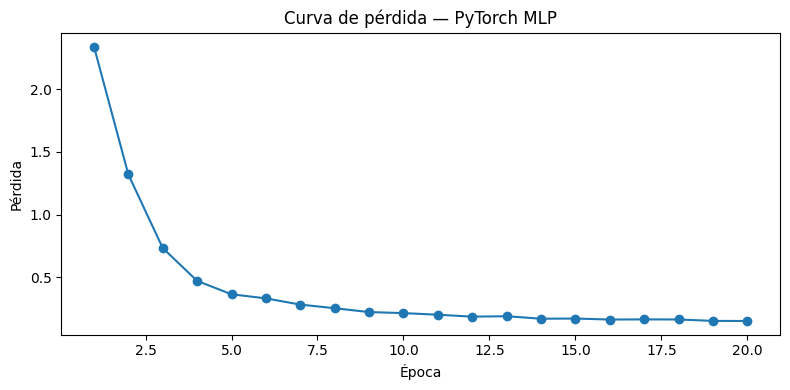

In [12]:
import matplotlib.pyplot as plt

optimizer_pt = torch.optim.Adam(model_pt.parameters(), lr=0.001)
criterion_pt = nn.CrossEntropyLoss()
train_losses_pt = []

for epoch in range(20):
    model_pt.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        optimizer_pt.zero_grad()
        loss = criterion_pt(model_pt(xb), yb)
        loss.backward()
        optimizer_pt.step()
        epoch_loss += loss.item() * len(xb)
    avg_loss = epoch_loss / len(train_ds)
    train_losses_pt.append(avg_loss)
    print(f"Época {epoch+1:2d}/20 — Pérdida: {avg_loss:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, 21), train_losses_pt, marker='o')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('Curva de pérdida — PyTorch MLP')
plt.tight_layout()
plt.show()

### 3.5. Evaluación en conjunto de prueba

In [13]:
model_pt.eval()
correct = 0
with torch.no_grad():
    for xb, yb in test_loader:
        preds = model_pt(xb).argmax(dim=1)
        correct += (preds == yb).sum().item()

accuracy_pt = correct / len(test_ds)
print(f"Exactitud en conjunto de prueba (PyTorch): {accuracy_pt:.4f} ({accuracy_pt*100:.2f}%)")

Exactitud en conjunto de prueba (PyTorch): 0.9031 (90.31%)


## 4. MLP con TensorFlow/Keras

### 4.1. Construcción del modelo

In [28]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # Esto es para unos mensaje de información que me salían en CUDA

import tensorflow as tf

model_tf = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64,  activation='relu'),
    tf.keras.layers.Dense(19,  activation='softmax'),
])
model_tf.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │         9,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 19)             │         1,235 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,371 (204.57 KB)

 Trainable params: 52,371 (204.57 KB)

 Non-trainable params: 0 (0.00 B)

### 4.2. Compilación del modelo

In [29]:
model_tf.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

### 4.3. Entrenamiento y curva de pérdida

Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.4556 - loss: 2.0443
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7534 - loss: 0.8526
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8593 - loss: 0.4539
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8890 - loss: 0.3390
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9084 - loss: 0.2691
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9152 - loss: 0.2399
Epoch 7/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9207 - loss: 0.2205
Epoch 8/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9294 - loss: 0.1972
Epoch 9/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9394 - loss: 0.1696
Epoch 10/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9354 - loss: 0.1719
Epoch 11/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9394 - loss: 0.1605
Epoch 12/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9488 - l

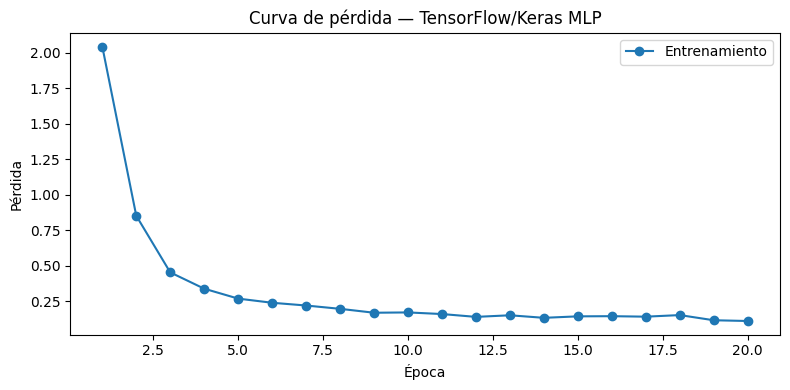

In [30]:
history = model_tf.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    verbose=1,
)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 21), history.history['loss'], marker='o', label='Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('Curva de pérdida — TensorFlow/Keras MLP')
plt.legend()
plt.tight_layout()
plt.show()

### 4.4. Evaluación en conjunto de prueba

In [31]:
_, accuracy_tf = model_tf.evaluate(X_test, y_test, verbose=0)
print(f"Precisión en conjunto de prueba (TensorFlow): {accuracy_tf:.4f} ({accuracy_tf*100:.2f}%)")

Precisión en conjunto de prueba (TensorFlow): 0.9277 (92.77%)


## 5. Comparación de resultados

### 5.1. Matrices de confusión

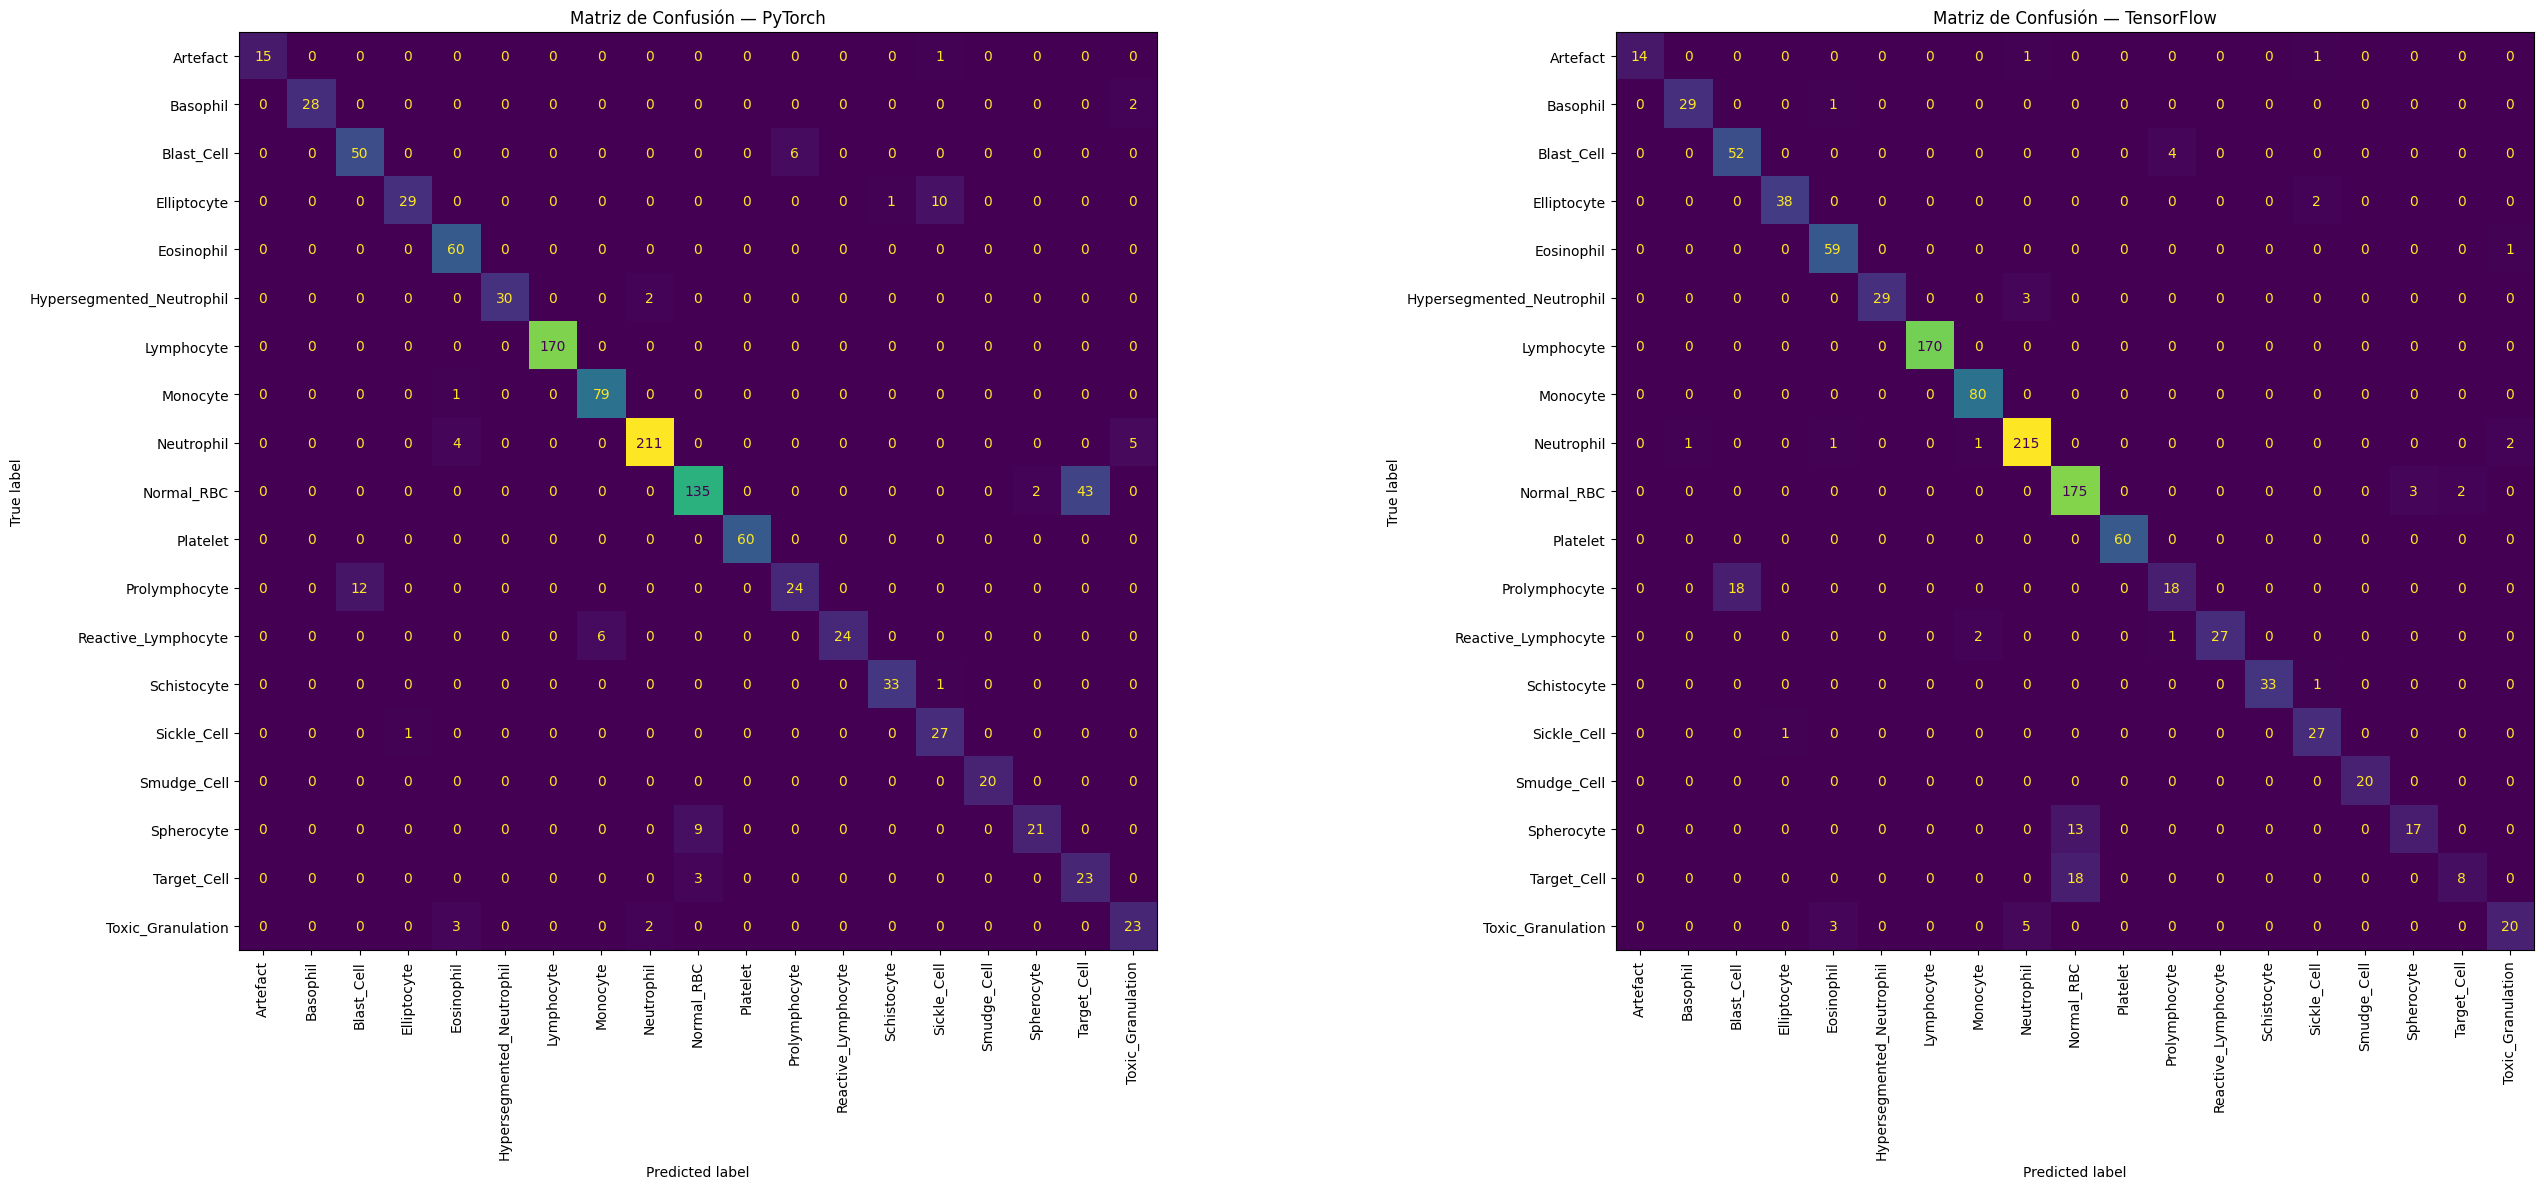

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model_pt.eval()
with torch.no_grad():
    y_pred_pt = model_pt(X_test_t).argmax(dim=1).numpy()

y_pred_tf = model_tf.predict(X_test, verbose=0).argmax(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(28, 12))

cm_pt = confusion_matrix(y_test, y_pred_pt)
ConfusionMatrixDisplay(cm_pt, display_labels=le.classes_).plot(ax=axes[0], xticks_rotation=90, colorbar=False)
axes[0].set_title('Matriz de Confusión — PyTorch')

cm_tf = confusion_matrix(y_test, y_pred_tf)
ConfusionMatrixDisplay(cm_tf, display_labels=le.classes_).plot(ax=axes[1], xticks_rotation=90, colorbar=False)
axes[1].set_title('Matriz de Confusión — TensorFlow')

plt.tight_layout()
plt.show()

### 5.2. Tipos de célula más difíciles de clasificar

In [ ]:
from sklearn.metrics import classification_report

report_pt = classification_report(y_test, y_pred_pt, target_names=le.classes_, output_dict=True)
report_tf = classification_report(y_test, y_pred_tf, target_names=le.classes_, output_dict=True)

recalls_pt = sorted([(c, report_pt[c]['recall']) for c in le.classes_], key=lambda x: x[1])
recalls_tf = sorted([(c, report_tf[c]['recall']) for c in le.classes_], key=lambda x: x[1])

print("PyTorch - clases con menor recall:")
for cls, rec in recalls_pt[:5]:
    print(f" - {cls}: {rec:.3f}")

print("\nTensorFlow - clases con menor recall:")
for cls, rec in recalls_tf[:5]:
    print(f" - {cls}: {rec:.3f}")

coincidences = set(c for c, _ in recalls_pt[:5]) & set(c for c, _ in recalls_tf[:5])
print(f"\nClases difíciles en común: {coincidences if coincidences else 'Ninguna'}")

PyTorch - clases con menor recall (más difíciles):
 - Prolymphocyte: 0.667
 - Spherocyte: 0.700
 - Elliptocyte: 0.725
 - Normal_RBC: 0.750
 - Reactive_Lymphocyte: 0.800

TensorFlow - clases con menor recall (más difíciles):
 - Target_Cell: 0.308
 - Prolymphocyte: 0.500
 - Spherocyte: 0.567
 - Toxic_Granulation: 0.714
 - Artefact: 0.875

Clases difíciles en común: {'Prolymphocyte', 'Spherocyte'}


Los tipos de célula con menor recall son los que ambos modelos confunden con mayor frecuencia. En este caso, podemos ver que las clases difíciles en común son Prolymphocyte y Spherocyte. No obstante, no necesariamente ambos modelos confundirán exactamente las mismas clases, ya que cada framework puede tener diferencias en la optimización y representación de los datos. Sin embargo, si las clases difíciles coinciden entre PyTorch y TensorFlow, esto indicaría que la dificultad es intrínseca al problema y no un artefacto de un framework en particular.

### 5.3. Comparación de precisión: PyTorch vs TensorFlow

In [37]:
print(f"{'Modelo':<25} {'Precisión (accuracy)':>20}")
print("-" * 46)
print(f"{'PyTorch MLP':<25} {accuracy_pt:>19.4f}")
print(f"{'TensorFlow/Keras MLP':<25} {accuracy_tf:>19.4f}")
print("-" * 46)
print(f"{'Diferencia':<25} {abs(accuracy_pt - accuracy_tf):>19.4f}")
mejor = 'PyTorch' if accuracy_pt >= accuracy_tf else 'TensorFlow'
print(f"\nMejor modelo: {mejor}")

Modelo                    Precisión (accuracy)
----------------------------------------------
PyTorch MLP                            0.9031
TensorFlow/Keras MLP                   0.9277
----------------------------------------------
Diferencia                             0.0247

Mejor modelo: TensorFlow


Podemos visualizar que el modelo entrenado con TensorFlow/Keras obtuvo una precisión ligeramente superior a la del modelo entrenado con PyTorch. Esto podría deberse a diferencias a la aleatoriedad (en mi caso, ejecuté varias veces el notebook y me dieron resultados relativamente diferentes, no sé si haya alguna forma de "congelar" la semilla) inherente al proceso de entrenamiento. Sin embargo, es importante destacar que ambos modelos lograron una precisión bastante similar, lo que sugiere que el enfoque general de MLP es adecuado para este problema, independientemente del framework utilizado. 